In [4]:
import pickle
import numpy as np
import os

In [13]:

import torch


device = "cuda" if torch.cuda.is_available() else "cpu"

In [14]:
def load_batch(file):
    with open(file, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
        X = batch[b'data']
        y = batch[b'labels']
        return X, y

In [15]:
def load_cifar10(dataset_dir):
    X_train = []
    y_train = []

    for i in range(1, 6):
        X, y = load_batch(os.path.join(dataset_dir, f"data_batch_{i}"))
        X_train.append(X)
        y_train.extend(y)

    X_train = np.concatenate(X_train)
    y_train = np.array(y_train)

    X_test, y_test = load_batch(os.path.join(dataset_dir, "test_batch"))
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    return X_train, y_train, X_test, y_test

In [16]:
dataset_dir = r"C:\ornekler\jupyter\deep_learning\odev1\cifar-10-batches-py"
X_train, y_train, X_test, y_test = load_cifar10(dataset_dir)

print(X_train.shape)
print(X_test.shape)

(50000, 3072)
(10000, 3072)


cifar10 dataset 32*32*3 = 3072 özellik

In [32]:
num_train = 5000
num_test = 500

X_train = X_train[:num_train]
y_train = y_train[:num_train]


In [33]:
# float'a çevir
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)


In [34]:
import numpy as np

class KNearestNeighbor:
    
    def __init__(self, k=1, distance='L2'):
        """
        k: kaç komşuya bakılacak
        distance: 'L1' veya 'L2'
        """
        self.k = k
        if distance not in ['L1', 'L2']:
            raise ValueError("distance parametresi 'L1' veya 'L2' olmalı")
        self.distance = distance

    def train(self, X, y):
        """
        Eğitim verisini sakla
        """
        self.Xtr = X
        self.ytr = y

    def predict(self, X):
        """
        Test verisi için tahmin
        """
        num_test = X.shape[0]
        Ypred = np.zeros(num_test, dtype=self.ytr.dtype)

        for i in range(num_test):
            if self.distance == 'L1':
                # Manhattan Mesafesi
                distances = np.sum(np.abs(self.Xtr - X[i, :]), axis=1)
            else:
                # Euclidean Mesafesi
                distances = np.sqrt(np.sum((self.Xtr - X[i, :])**2, axis=1))

            # k en küçük mesafenin indexleri
            knn_indices = np.argsort(distances)[:self.k]
            knn_labels = self.ytr[knn_indices]

            # en sık görülen etiketi al
            values, counts = np.unique(knn_labels, return_counts=True)
            Ypred[i] = values[np.argmax(counts)]

        return Ypred

In [ ]:
# Doğruluk hesaplama fonksiyonu
def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# k değerleri
k_values = [1,3,5,7,8,9]

# Sonuçları saklamak için
results_L1 = {}
results_L2 = {}

# L1 ve L2 için hesapla
for k in k_values:
    # L1
    knn_L1 = KNearestNeighbor(k=k, distance='L1')
    knn_L1.train(X_train, y_train)
    y_pred_L1 = knn_L1.predict(X_test)
    acc_L1 = compute_accuracy(y_test, y_pred_L1)
    results_L1[k] = acc_L1

    # L2
    knn_L2 = KNearestNeighbor(k=k, distance='L2')
    knn_L2.train(X_train, y_train)
    y_pred_L2 = knn_L2.predict(X_test)
    acc_L2 = compute_accuracy(y_test, y_pred_L2)
    results_L2[k] = acc_L2

In [147]:
print("k değerleri için doğruluklar:")

for k in k_values:
    print(f"k = {k} | L1 Accuracy: {results_L1[k]*100:.2f}% | L2 Accuracy: {results_L2[k]*100:.2f}%")

k değerleri için doğruluklar:
k = 1 | L1 Accuracy: 28.67% | L2 Accuracy: 26.67%
k = 3 | L1 Accuracy: 27.67% | L2 Accuracy: 27.00%
k = 5 | L1 Accuracy: 29.67% | L2 Accuracy: 28.33%
k = 7 | L1 Accuracy: 27.67% | L2 Accuracy: 29.67%
k = 9 | L1 Accuracy: 27.67% | L2 Accuracy: 30.00%


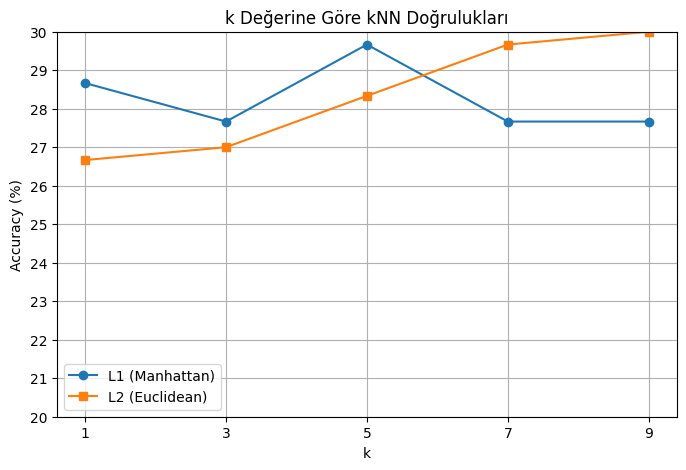

In [148]:
import matplotlib.pyplot as plt
# Matplotlib ile görselleştir
plt.figure(figsize=(8,5))

# Yüzdeye çevirelim
plt.plot(k_values, [results_L1[k]*100 for k in k_values], marker='o', label='L1 (Manhattan)')
plt.plot(k_values, [results_L2[k]*100 for k in k_values], marker='s', label='L2 (Euclidean)')

plt.title('k Değerine Göre kNN Doğrulukları')
plt.xlabel('k')
plt.ylabel('Accuracy (%)')
plt.xticks(k_values)
plt.yticks(np.arange(20, 31, 1))  # 20% - 30% arası
plt.ylim(20, 30)
plt.grid(True)
plt.legend()
plt.show()

In [141]:
new_k_values = [1,3,5,7,9,10,11,13,15,17,20]
nresults_L1 = {}
nresults_L2 = {}
for k in new_k_values:
    knn_L1 = KNearestNeighbor(k=k, distance='L1')
    knn_L1.train(X_train, y_train)
    y_pred_L1 = knn_L1.predict(X_test)
    acc_L1 = compute_accuracy(y_test, y_pred_L1)
    nresults_L1[k] = acc_L1

    # L2
    knn_L2 = KNearestNeighbor(k=k, distance='L2')
    knn_L2.train(X_train, y_train)
    y_pred_L2 = knn_L2.predict(X_test)
    acc_L2 = compute_accuracy(y_test, y_pred_L2)
    nresults_L2[k] = acc_L2

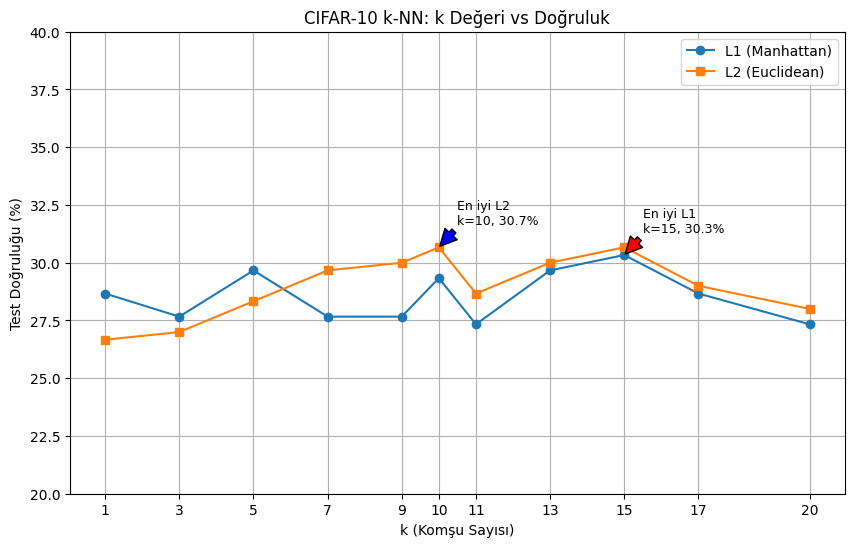

In [142]:
import matplotlib.pyplot as plt

# Matplotlib ile görselleştirme
plt.figure(figsize=(10,6))

# L1 ve L2 yüzdelik olarak
plt.plot(new_k_values, [nresults_L1[k]*100 for k in new_k_values], marker='o', label='L1 (Manhattan)')
plt.plot(new_k_values, [nresults_L2[k]*100 for k in new_k_values], marker='s', label='L2 (Euclidean)')

plt.title('CIFAR-10 k-NN: k Değeri vs Doğruluk')
plt.xlabel('k (Komşu Sayısı)')
plt.ylabel('Test Doğruluğu (%)')

# Y-ekseni aralığını ayarlayabiliriz, küçük veri setinde %20–%40 mantıklı
plt.ylim(20, 40)
plt.xticks(new_k_values)
plt.grid(True)
plt.legend()

# En iyi noktaları işaretlemek (opsiyonel)
best_k_L1 = max(nresults_L1, key=nresults_L1.get)
best_k_L2 = max(nresults_L2, key=nresults_L2.get)

plt.annotate(f'En iyi L1\nk={best_k_L1}, {nresults_L1[best_k_L1]*100:.1f}%',
             xy=(best_k_L1, nresults_L1[best_k_L1]*100), xytext=(best_k_L1+0.5, nresults_L1[best_k_L1]*100+1),
             arrowprops=dict(facecolor='red', shrink=0.05), fontsize=9)

plt.annotate(f'En iyi L2\nk={best_k_L2}, {nresults_L2[best_k_L2]*100:.1f}%',
             xy=(best_k_L2, nresults_L2[best_k_L2]*100), xytext=(best_k_L2+0.5, nresults_L2[best_k_L2]*100+1),
             arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=9)

plt.show()

In [39]:
# Sınıf bazında doğruluk hesaplama
def class_wise_accuracy(y_true, y_pred, num_classes=10):
    accuracies = np.zeros(num_classes)
    for cls in range(num_classes):
        idx = (y_true == cls)  # Bu sınıfa ait örnekler
        if np.sum(idx) > 0:
            accuracies[cls] = np.mean(y_pred[idx] == y_true[idx])
    return accuracies

In [ ]:
k = 1

# L1
knn_L1 = KNearestNeighbor(k=k, distance='L1')
knn_L1.train(X_train, y_train)
y_pred_L1 = knn_L1.predict(X_test)
acc_L1_classes = class_wise_accuracy(y_test, y_pred_L1)

# L2
knn_L2 = KNearestNeighbor(k=k, distance='L2')
knn_L2.train(X_train, y_train)
y_pred_L2 = knn_L2.predict(X_test)
acc_L2_classes = class_wise_accuracy(y_test, y_pred_L2)

# Sınıf isimleri (CIFAR-10)
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Yazdır
print("k=10 için sınıf bazında doğruluk (L1 - Manhattan):")
for i, cls in enumerate(classes):
    print(f"{cls:10s}: {acc_L1_classes[i]*100:.2f}%")

print("\nk=10 için sınıf bazında doğruluk (L2 - Euclidean):")
for i, cls in enumerate(classes):
    print(f"{cls:10s}: {acc_L2_classes[i]*100:.2f}%")

k=10 için sınıf bazında doğruluk (L1 - Manhattan):
airplane  : 42.10%
automobile: 15.10%
bird      : 29.30%
cat       : 11.00%
deer      : 40.00%
dog       : 12.70%
frog      : 27.20%
horse     : 15.10%
ship      : 46.70%
truck     : 17.40%

k=10 için sınıf bazında doğruluk (L2 - Euclidean):
airplane  : 42.80%
automobile: 9.50%
bird      : 27.10%
cat       : 10.90%
deer      : 43.70%
dog       : 14.10%
frog      : 23.90%
horse     : 11.30%
ship      : 45.30%
truck     : 12.30%
